In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import pointbiserialr
from scipy.spatial.distance import pdist
from sklearn.preprocessing import LabelEncoder


# Clustering Correlation

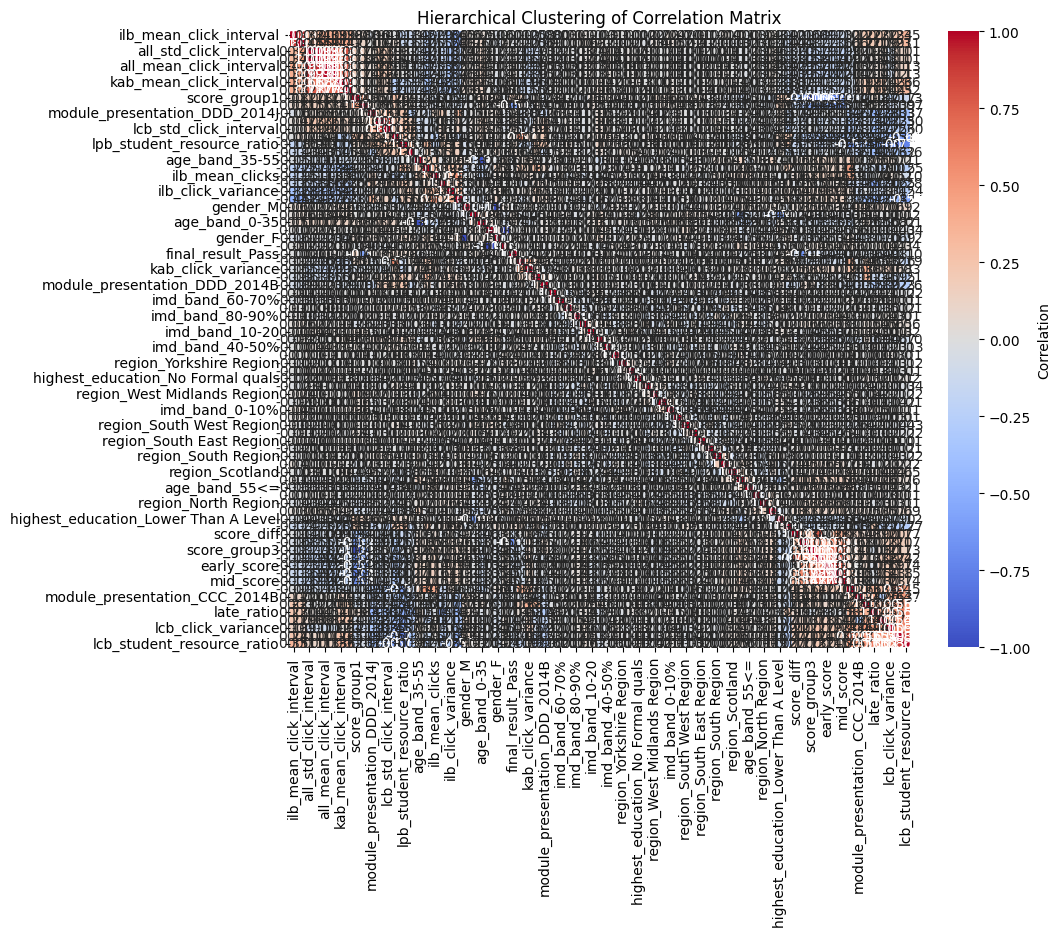

In [21]:
clustering_method = 'average'  # 可選擇 'single', 'complete', 'average', 'ward'

# Step 1: 讀取資料並進行分組
df = pd.read_csv("data_0510_3c.csv")
df = df[df['score'] != 'group2']
# df = df[[col for col in df.columns if 'mean_clicks' in col]]

# drop_names = ['dataplus', 'sharedsubpage', 'questionnaire', 'dualpane', 'repeatactivity', 'folder', 'htmlactivity']
# for name in drop_names:
#     df = df.drop(columns=[col for col in df.columns if name in col])

# missing_percent = df.isnull().mean() * 100
# # 找出缺值超過某個比例的欄位（例如 50%）
# threshold = 50  # 你可以改成任何比例
# cols_to_drop = missing_percent[missing_percent > threshold].index
# print(f"建議刪掉的欄位：{list(cols_to_drop)}")

# df = df.drop(columns=list(cols_to_drop))
# df.drop(columns=['weight', 'is_banked', 'assessment_type', 'id_assessment', 'id_student', 'date_unregistration', 'date', 'final_result'], inplace=True)

# 假設 'score' 欄位存在，並依照其值由高到低切分為五組
# df['score'] = pd.qcut(df['score'], 5, labels=['group1', 'group2', 'group3', 'group4', 'group5'])

# Step 2: 計算相關矩陣，處理缺值
# 這裡手動處理名義變數和數值變數的相關性

# Step 3: 使用 One-Hot Encoding 處理類別變數
df = pd.get_dummies(df)  

# 計算 Pearson 相關矩陣（數值變數）
corr_matrix = df.corr(method='pearson')
corr_matrix = corr_matrix.fillna(0)  # 將 NaN 替換為 0

# Step 4: 進行階層分群並重新排列
# 先將相關矩陣轉為距離矩陣（1-相關性），因為階層分群使用的是距離
distance_matrix = 1 - corr_matrix

# 使用 linkage 計算階層分群，方法可以選擇 "average", "single", "complete" 等
Z = linkage(pdist(distance_matrix), method=clustering_method)

# 根據階層分群的結果排序相關矩陣
dendro = dendrogram(Z, no_plot=True)
ordered_idx = dendro['leaves']

# 重新排列相關矩陣
ordered_corr_matrix = corr_matrix.iloc[ordered_idx, ordered_idx]

# 儲存排序後的結果到 clustcorr.csv
ordered_corr_matrix.to_csv(f'clustcorr_{clustering_method}.csv')

# Step 5: 畫色溫圖
plt.figure(figsize=(10, 8))
sns.heatmap(ordered_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar_kws={'label': 'Correlation'})
plt.title('Hierarchical Clustering of Correlation Matrix')
plt.show()


In [13]:
distance_matrix

,all_mean_clicks,all_click_variance,forumng_mean_clicks,forumng_click_variance,homepage_mean_clicks,homepage_click_variance,oucontent_mean_clicks,oucontent_click_variance,subpage_mean_clicks,subpage_click_variance,...,quiz_mean_clicks,quiz_click_variance,ouelluminate_mean_clicks,ouelluminate_click_variance,page_mean_clicks,page_click_variance,externalquiz_mean_clicks,externalquiz_click_variance,ouwiki_mean_clicks,ouwiki_click_variance
all_mean_clicks,0.000000,0.742226,0.625220,0.928869,0.532236,0.841016,0.582238,0.801382,0.858262,0.882320,...,0.404388,0.791524,0.864218,0.730437,0.914740,0.840877,0.948562,0.772585,0.785742,0.771902
all_click_variance,0.742226,0.000000,1.058262,1.045027,0.941170,0.681276,0.799938,0.858104,1.107213,0.858849,...,0.645244,0.614413,0.987096,1.000953,0.952362,0.954705,0.926929,1.000375,0.846360,0.907358
forumng_mean_clicks,0.625220,1.058262,0.000000,0.714614,0.709096,0.933576,1.006223,0.898908,0.855085,0.890497,...,0.940557,0.963726,0.922115,0.872619,0.986952,0.968635,0.985086,0.910291,0.793580,0.944293
forumng_click_variance,0.928869,1.045027,0.714614,0.000000,0.808682,0.881006,1.058744,0.925999,0.777534,0.863524,...,0.948883,0.878246,0.965692,0.855399,0.969581,0.959452,0.964948,0.822231,0.899451,0.781663
homepage_mean_clicks,0.532236,0.941170,0.709096,0.808682,0.000000,0.498466,0.941022,0.882718,0.731674,0.862168,...,0.873328,0.777168,0.871346,0.747376,0.976546,0.886375,0.993426,0.852947,0.937020,0.871939
homepage_click_variance,0.841016,0.681276,0.933576,0.881006,0.498466,0.000000,0.935890,0.930876,0.895251,0.851136,...,0.907663,0.801714,0.967056,0.941622,0.980093,0.942906,1.008501,0.956846,0.900481,0.918610
oucontent_mean_clicks,0.582238,0.799938,1.006223,1.058744,0.941022,0.935890,0.000000,0.666793,1.039911,0.976889,...,0.985182,0.911988,1.059274,1.078964,0.939977,0.922884,0.973302,0.990842,0.890765,0.964444
oucontent_click_variance,0.801382,0.858104,0.898908,0.925999,0.882718,0.930876,0.666793,0.000000,0.937181,0.896641,...,0.989079,0.885302,0.977913,0.941409,0.954971,0.916945,0.973283,0.924273,0.936506,0.926058
subpage_mean_clicks,0.858262,1.107213,0.855085,0.777534,0.731674,0.895251,1.039911,0.937181,0.000000,0.497025,...,0.732172,0.820965,0.921580,0.847939,0.915667,0.950944,0.920116,0.810546,0.856053,0.838268
subpage_click_variance,0.882320,0.858849,0.890497,0.863524,0.862168,0.851136,0.976889,0.896641,0.497025,0.000000,...,0.876299,0.794279,0.896774,0.929267,0.878127,0.929483,0.996578,0.885486,0.952645,0.905455


In [13]:
data = pd.read_csv("./full_data2c.csv")
data = data[['code_module', 'code_presentation', 'id_student']]
vle = pd.read_csv("./studentVle.csv")
# vle['module_presentation'] = vle['code_module'] + vle['code_presentation']

df = data.merge(vle, on=['code_module', 'code_presentation', 'id_student'], how='inner')
df.groupby(['code_module', 'code_presentation', 'id_student', 'date']).size().describe()

count    329648.000000
mean          5.598253
std           5.087362
min           1.000000
25%           2.000000
50%           4.000000
75%           7.000000
max         223.000000
dtype: float64

In [18]:
df.groupby(['code_module', 'code_presentation', 'id_student', 'date']).size()

code_module  code_presentation  id_student  date
CCC          2014B              29764       -18      4
                                            -17      6
                                            -16      1
                                            -5       2
                                            -3       1
                                                    ..
DDD          2014J              2685863      239    11
                                             240    10
                                             242     1
                                             246     6
                                             255     4
Length: 329648, dtype: int64

In [19]:
329648 / 3374

97.70243034973325

In [40]:
data = pd.read_csv("./full_data2c.csv")
data.head(15)

,code_module,code_presentation,id_assessment,assessment_type,date,weight,id_student,date_submitted,is_banked,score,...,output_std_click_interval,output_mean_clicks,output_click_variance,homepage_student_resource_ratio,input_student_resource_ratio,output_student_resource_ratio,early_score,late_score,mid_score,score_diff
0,CCC,2014B,24290,Exam,NaN,100.0,558914,230,0,group1,...,2.243116,11.926829,0.996728,0.255961,0.229663,0.514376,51.666667,27.5,19.000000,-24.166667
1,CCC,2014B,24290,Exam,NaN,100.0,559706,234,0,group3,...,12.693074,22.840000,1.214273,0.163522,0.437456,0.399022,47.000000,66.5,60.000000,19.500000
2,CCC,2014B,24290,Exam,NaN,100.0,559770,230,0,group1,...,1.132184,23.944056,1.864376,0.143876,0.116440,0.739685,65.333333,55.0,67.000000,-10.333333
3,CCC,2014B,24290,Exam,NaN,100.0,560311,234,0,group3,...,6.351597,31.939394,1.818733,0.142162,0.173645,0.684193,93.333333,88.5,94.000000,-4.833333
4,CCC,2014B,24290,Exam,NaN,100.0,560494,230,0,group3,...,3.089647,11.432836,1.643969,0.248841,0.159196,0.591963,91.500000,75.5,76.000000,-16.000000
5,CCC,2014B,24290,Exam,NaN,100.0,561363,230,0,group3,...,16.972488,21.421053,0.714164,0.136205,0.389988,0.473807,72.666667,70.0,78.333333,-2.666667
6,CCC,2014B,24290,Exam,NaN,100.0,561559,230,0,group1,...,10.648242,37.677419,1.063427,0.121585,0.346539,0.531876,80.666667,65.0,75.333333,-15.666667
7,CCC,2014B,24290,Exam,NaN,100.0,562450,230,0,group1,...,18.359963,26.684211,0.847190,0.167630,0.246243,0.586127,78.000000,61.0,88.000000,-17.000000
8,CCC,2014B,24290,Exam,NaN,100.0,562825,230,0,group1,...,14.865428,19.312500,0.768395,0.185321,0.247706,0.566972,65.333333,40.5,67.000000,-24.833333
9,CCC,2014B,24290,Exam,NaN,100.0,563046,230,0,group1,...,15.170491,16.684211,1.232038,0.176471,0.222011,0.601518,63.333333,51.0,62.500000,-12.333333


In [28]:
data.describe()

,studied_credits,late_ratio,completion_ratio,homepage_mean_click_interval,homepage_std_click_interval,homepage_mean_clicks,homepage_click_variance,input_mean_click_interval,input_std_click_interval,input_mean_clicks,input_click_variance,output_mean_click_interval,output_std_click_interval,output_mean_clicks,output_click_variance,early_score,late_score,mid_score
count,3375.000000,3372.000000,3375.000000,3374.000000,3374.000000,3374.000000,3374.000000,3372.000000,3370.000000,3372.000000,3372.000000,3357.000000,3347.000000,3370.000000,3370.000000,3369.000000,3094.000000,3357.000000
mean,76.416296,0.409186,0.913565,3.801479,4.196824,3.322337,0.851012,5.239135,6.167019,8.186796,1.083762,8.655542,10.955555,15.236889,1.049077,79.150510,67.605904,73.731278
std,34.458854,0.326612,0.162019,3.147915,4.254655,1.355769,0.170227,4.861924,4.239432,4.526768,0.437382,9.502685,11.814293,13.661575,0.310988,14.224461,22.761255,18.397214
min,30.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.049180,0.216689,1.727273,0.306186,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,8.000000
25%,60.000000,0.000000,0.875000,2.165217,2.072517,2.519231,0.749944,3.077729,3.395413,5.454559,0.869318,3.463768,4.000644,5.580833,0.845922,70.400000,50.750000,60.500000
50%,60.000000,0.500000,1.000000,3.101769,3.253718,3.043717,0.831120,4.345804,5.221510,7.515207,0.999732,5.875000,7.566292,9.346053,1.012931,81.666667,71.166667,77.000000
75%,90.000000,0.625000,1.000000,4.536706,5.148176,3.726090,0.927115,6.282967,7.986337,9.811432,1.177155,10.409091,14.031482,21.539991,1.209847,90.000000,87.000000,89.333333
max,280.000000,1.250000,1.000000,76.000000,92.790984,23.539286,4.070581,220.000000,82.211979,71.348837,7.935843,186.000000,139.300036,118.000000,4.059936,100.000000,100.000000,100.000000


In [41]:
data['module_presentation'] = data['code_module'] + data['code_presentation']
data.drop(columns=['code_module','code_presentation', 'id_assessment','assessment_type','date','weight','id_student','date_submitted','is_banked','date_registration','date_unregistration', 'num_of_prev_attempts'], inplace=True)
data.drop(columns=['disability', 'avg_score', 'final_result', 'score_diff', 'homepage_student_resource_ratio','input_student_resource_ratio','output_student_resource_ratio'], inplace=True)
data.columns

Index(['score', 'gender', 'region', 'highest_education', 'imd_band',
       'age_band', 'studied_credits', 'late_ratio', 'completion_ratio',
       'homepage_mean_click_interval', 'homepage_std_click_interval',
       'homepage_mean_clicks', 'homepage_click_variance',
       'input_mean_click_interval', 'input_std_click_interval',
       'input_mean_clicks', 'input_click_variance',
       'output_mean_click_interval', 'output_std_click_interval',
       'output_mean_clicks', 'output_click_variance', 'early_score',
       'late_score', 'mid_score', 'module_presentation'],
      dtype='object')

In [35]:
data.groupby('disability').size()

disability
N    2578
Y     233
dtype: int64

In [42]:
# test_data = data.drop(columns=['late_score'])
data.dropna(inplace=True)
data.shape

(2811, 25)

In [43]:
data.to_csv("data_0521.csv", index=False)

In [44]:
base_df = data[['score', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'module_presentation']]
base_df.to_csv("data_0521_base.csv", index=False)